# 🎓 Paper Support: EDA Dataset & Evaluasi Model Multimodal Ensemble
### 🏆 Gemastik 2026 — Dukungan Data & Visualisasi untuk Paper

Notebook ini menyediakan seluruh angka dan visualisasi yang dibutuhkan untuk paper, dengan struktur tabel perbandingan **Visual / Audio / Ensemble** × **Fine-tuning Tidak/Ya** yang **dihitung langsung (live)** di notebook ini pada set test independen yang sama:

1. 🔍 **EDA Dataset Latih (Train):** jumlah sampel, distribusi kelas, durasi video, FPS, dan resolusi.
2. 🧪 **EDA Dataset Uji (Test):** jumlah sampel, distribusi kelas, dan perbandingan proporsi Train vs Test.
3. 🤖 **Menjalankan model:** **base model zero-shot** (Video ViT `dima806` + Audio Wav2Vec2 `MelodyMachine`) untuk baris **Tidak**, dan **Ensemble Multimodal 50/50 hasil fine-tuning** (5-Fold soft-voting) untuk baris **Ya**.
4. 📊 **Visualisasi perbandingan setiap model:** bar chart Accuracy/Precision/Recall/F1 per modalitas (Fine-tuning Tidak vs Ya).


In [1]:
!pip install -q transformers torchaudio librosa soundfile scikit-learn matplotlib seaborn tqdm pandas opencv-python-headless pillow
# 1. Setup Environment & Import Libraries
import os
import glob
import shutil
import random
import zipfile
import subprocess
import json
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import librosa
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from transformers import AutoImageProcessor, AutoModelForImageClassification, AutoFeatureExtractor, AutoModelForAudioClassification

# Set seeds for 100% reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Optional: Mount Google Drive if in Google Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("✅ Google Drive mounted.")
except Exception:
    print("ℹ️ Not running on Google Colab or Drive already mounted.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Execution Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 Active GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB VRAM)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted.
🖥️ Execution Device: cuda
🎮 Active GPU: Tesla T4 (15.64 GB VRAM)


In [2]:
# 2. Setup Base Directory & Drive Paths
DRIVE_DATASET_DIR = "/content/drive/MyDrive/Gemastik26/Dataset Indonesia"
MODEL_SAVE_DIR = "/content/drive/MyDrive/Gemastik26/models/revision1"
AUDIO_MODEL_SAVE_DIR = "/content/drive/MyDrive/Gemastik26/models/revision1_v2"  # v2 audio checkpoints
KFOLD_SPLIT_FILE = "/content/drive/MyDrive/Gemastik26/kfold_splits.json"

LOCAL_RAW_DIR = "/content/dataset_raw"
LOCAL_RAW_TEST_DIR = "/content/dataset_raw_test"
LOCAL_AUDIO_TEST_DIR = "/content/dataset_audio_test_16k"
CLASSES = ["Real", "AI"]
DISPLAY_LABELS = ["Asli", "AI-Generated"]  # 0=Real/Asli, 1=AI/AI-Generated
SAMPLE_RATE = 16000
MAX_AUDIO_SAMPLES = int(SAMPLE_RATE * 5.0)  # 5.0 seconds = 80,000 samples

print(f"📁 Video Model Save Directory: {MODEL_SAVE_DIR}")
print(f"🎙️ Audio Model Save Directory: {AUDIO_MODEL_SAVE_DIR}")
print(f"🛡️ 5-Fold Split File: {KFOLD_SPLIT_FILE}")


📁 Video Model Save Directory: /content/drive/MyDrive/Gemastik26/models/revision1
🎙️ Audio Model Save Directory: /content/drive/MyDrive/Gemastik26/models/revision1_v2
🛡️ 5-Fold Split File: /content/drive/MyDrive/Gemastik26/kfold_splits.json


In [3]:
# 3. Unzip Dataset Latih (train.zip & trainAI.zip) dan Dataset Uji (testReal.zip & testAI.zip)
TRAIN_ZIP_PATHS = {
    "Real": [os.path.join(DRIVE_DATASET_DIR, "Real", "train.zip"), os.path.join(DRIVE_DATASET_DIR, "train.zip")],
    "AI": [os.path.join(DRIVE_DATASET_DIR, "AI", "trainAI.zip"), os.path.join(DRIVE_DATASET_DIR, "trainAI.zip")],
}
TEST_ZIP_PATHS = {
    "Real": [os.path.join(DRIVE_DATASET_DIR, "Real", "testReal.zip"), os.path.join(DRIVE_DATASET_DIR, "testReal.zip")],
    "AI": [os.path.join(DRIVE_DATASET_DIR, "AI", "testAI.zip"), os.path.join(DRIVE_DATASET_DIR, "testAI.zip")],
}

def unzip_file(zip_path, extract_to):
    print(f"📦 Unzipping '{zip_path}' -> '{extract_to}'...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"✅ Unzipped successfully to {extract_to}")

def smart_unzip(candidates, extract_target):
    if os.path.exists(extract_target) and len(os.listdir(extract_target)) > 0:
        print(f"⏭️ Target directory '{extract_target}' already exists. Skipping unzip.")
        return
    for p in candidates:
        if os.path.exists(p):
            unzip_file(p, extract_target)
            return
    print(f"⚠️ Zip file not found at candidates: {candidates}")

# Train
for cls, cands in TRAIN_ZIP_PATHS.items():
    smart_unzip(cands, os.path.join(LOCAL_RAW_DIR, cls))
# Test
for cls, cands in TEST_ZIP_PATHS.items():
    smart_unzip(cands, os.path.join(LOCAL_RAW_TEST_DIR, cls))

# Bangun daftar sampel video uji (untuk EDA test & inferensi ensemble)
test_video_samples = []
for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    for vf in glob.glob(os.path.join(cls_dir, "**", "*.mp4"), recursive=True):
        test_video_samples.append((vf, label_idx, Path(vf).stem))

print(f"\n🧪 Total sampel video uji ditemukan: {len(test_video_samples)}")
print("✅ Unzip + koleksi sampel selesai!")


⏭️ Target directory '/content/dataset_raw/Real' already exists. Skipping unzip.
⏭️ Target directory '/content/dataset_raw/AI' already exists. Skipping unzip.
⏭️ Target directory '/content/dataset_raw_test/Real' already exists. Skipping unzip.
⏭️ Target directory '/content/dataset_raw_test/AI' already exists. Skipping unzip.

🧪 Total sampel video uji ditemukan: 312
✅ Unzip + koleksi sampel selesai!


## 1️⃣ EDA Dataset Latih (Train)
Profil lengkap video latih: jumlah sampel per kelas, durasi (detik), FPS, dan resolusi — untuk bagian Deskripsi Dataset pada paper.


In [4]:
# 4. Profiling Metadata Seluruh Video Latih (Train)
def profile_videos(root_dir, dataset_name):
    records = []
    video_extensions = ("*.mp4", "*.avi", "*.mov", "*.mkv", "*.MP4", "*.AVI", "*.MOV", "*.MKV")
    print(f"🔍 Collecting metadata for {dataset_name} videos ...")
    for label_idx, cls in enumerate(CLASSES):
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.exists(cls_dir):
            continue
        vfiles = []
        for ext in video_extensions:
            vfiles.extend(glob.glob(os.path.join(cls_dir, "**", ext), recursive=True))
        for vf in tqdm(vfiles, desc=f"Profiling [{dataset_name} | {cls}]"):
            stem = Path(vf).stem
            cap = cv2.VideoCapture(vf)
            if not cap.isOpened():
                continue
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            duration = frame_count / fps if fps > 0 else 0.0
            cap.release()
            records.append({
                "video_path": vf, "stem": stem, "label": label_idx, "class": cls,
                "extension": Path(vf).suffix.lower(), "width": width, "height": height,
                "fps": round(fps, 2), "duration_sec": round(duration, 2),
                "est_1fps_frames": min(30, max(1, int(round(duration))))
            })
    # ⚠️ Dedup per (stem, class), BUKAN per stem saja! testReal.zip & testAI.zip berisi stem IDENTIK
    #    (AI diturunkan dari klip Real yang sama — lihat docs/revision1_audit.md, bug frame-cache stem
    #    collision). Dedup per stem saja akan menghapus SELURUH baris AI pada EDA test (duplicate of
    #    Real) sehingga kelas AI tidak tampil. Dedup per (stem, class) tetap membuang duplikat intra-kelas.
    df = pd.DataFrame(records).drop_duplicates(subset=["stem", "class"]).reset_index(drop=True)
    return df

df_train_eda = profile_videos(LOCAL_RAW_DIR, "TRAIN")

print("========================================================")
print("📊 RINGKASAN DATASET LATIH (TRAIN)")
print("========================================================")
print(f"Total Video Latih: {len(df_train_eda)}")
print("--- Distribusi Kelas ---")
train_dist = df_train_eda["class"].value_counts()
for c in CLASSES:
    n = train_dist.get(c, 0)
    print(f"{c:<8}: {n} video ({n / max(len(df_train_eda), 1) * 100:.2f}%)")
print("--- Ringkasan Statistik per Kelas ---")
display(df_train_eda.groupby("class")[["duration_sec", "fps", "width", "height"]].describe().T)


🔍 Collecting metadata for TRAIN videos ...


Profiling [TRAIN | Real]: 100%|██████████| 654/654 [00:09<00:00, 71.84it/s]
Profiling [TRAIN | AI]: 100%|██████████| 413/413 [00:03<00:00, 114.41it/s]


📊 RINGKASAN DATASET LATIH (TRAIN)
Total Video Latih: 1067
--- Distribusi Kelas ---
Real    : 654 video (61.29%)
AI      : 413 video (38.71%)
--- Ringkasan Statistik per Kelas ---


class                        AI         Real
duration_sec count   413.000000   654.000000
             mean     18.677966    77.254939
             std      49.333841    71.645396
             min       6.040000     3.270000
             25%       8.770000    39.235000
             50%      10.040000    61.230000
             75%      16.000000    95.785000
             max     962.000000   896.700000
fps          count   413.000000   654.000000
             mean     26.679492    29.025199
             std       3.072773     2.067406
             min      13.000000    22.010000
             25%      24.000000    30.000000
             50%      24.000000    30.000000
             75%      30.000000    30.000000
             max      30.000000    30.000000
width        count   413.000000   654.000000
             mean    507.641646   736.299694
             std     183.620724   117.061451
             min     288.000000   356.000000
             25%     360.000000   720.000000
             50%     360.000000   720.000000
             75%     720.000000   720.000000
             max    1080.000000  1280.000000
height       count   413.000000   654.000000
             mean    898.237288  1207.464832
             std     325.965261   221.670978
             min     430.000000   358.000000
             25%     640.000000  1280.000000
             50%     640.000000  1280.000000
             75%    1280.000000  1280.000000
             max    1920.000000  1920.000000

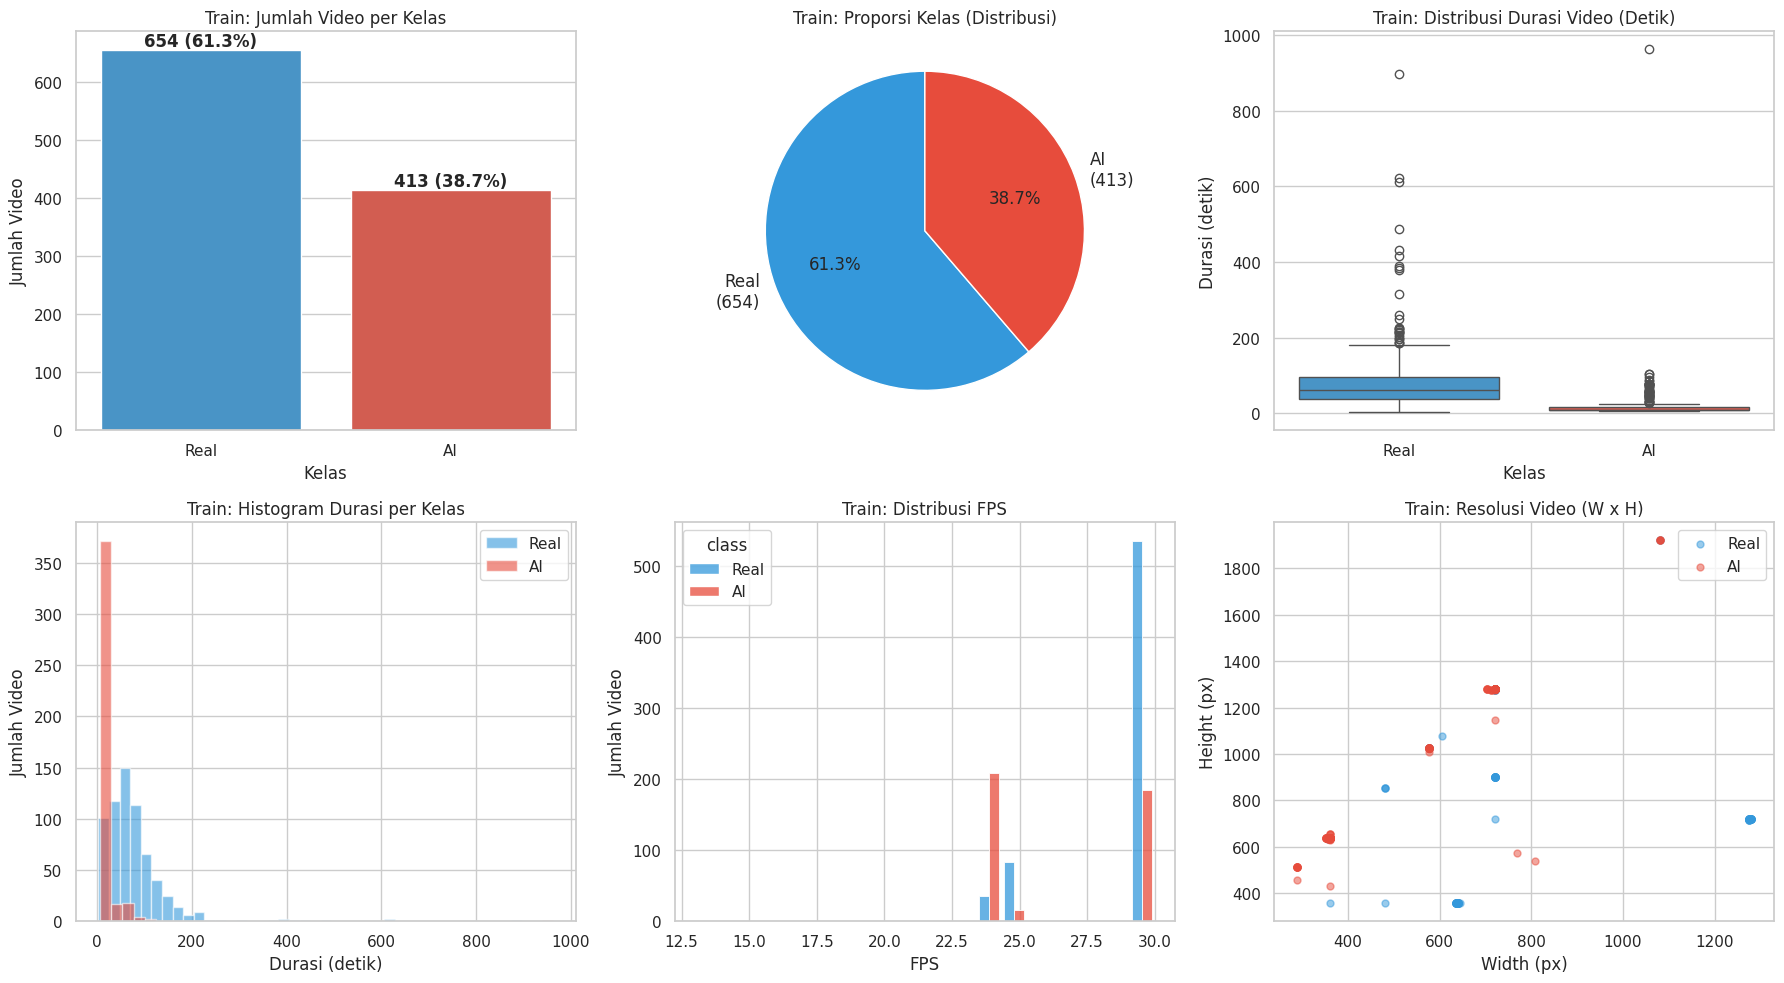

📌 Dataset Latih: 1067 video | Real: 654 | AI: 413


In [5]:
# 5. Visualisasi EDA Dataset Latih (Train)
sns.set_theme(style="whitegrid")
train_dist = df_train_eda["class"].value_counts()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1) Jumlah video per kelas
sns.countplot(data=df_train_eda, x="class", hue="class", legend=False, palette=["#3498db", "#e74c3c"], ax=axes[0][0])
for i, c in enumerate(CLASSES):
    axes[0][0].text(i, train_dist.get(c, 0), f"{train_dist.get(c, 0)} ({train_dist.get(c, 0) / len(df_train_eda) * 100:.1f}%)", ha="center", va="bottom", fontweight="bold")
axes[0][0].set_title("Train: Jumlah Video per Kelas")
axes[0][0].set_xlabel("Kelas"); axes[0][0].set_ylabel("Jumlah Video")

# 2) Pie chart proporsi kelas
axes[0][1].pie(train_dist.values, labels=[f"{c}\n({v})" for c, v in train_dist.items()], autopct="%1.1f%%",
               colors=["#3498db", "#e74c3c"], startangle=90, textprops={"fontsize": 12})
axes[0][1].set_title("Train: Proporsi Kelas (Distribusi)")

# 3) Durasi video
sns.boxplot(data=df_train_eda, x="class", y="duration_sec", hue="class", legend=False, palette=["#3498db", "#e74c3c"], ax=axes[0][2])
axes[0][2].set_title("Train: Distribusi Durasi Video (Detik)")
axes[0][2].set_xlabel("Kelas"); axes[0][2].set_ylabel("Durasi (detik)")

# 4) Durasi histogram
axes[1][0].hist(df_train_eda.loc[df_train_eda['class'] == 'Real', 'duration_sec'], bins=40, alpha=0.6, label="Real", color="#3498db")
axes[1][0].hist(df_train_eda.loc[df_train_eda['class'] == 'AI', 'duration_sec'], bins=40, alpha=0.6, label="AI", color="#e74c3c")
axes[1][0].set_title("Train: Histogram Durasi per Kelas")
axes[1][0].set_xlabel("Durasi (detik)"); axes[1][0].set_ylabel("Jumlah Video"); axes[1][0].legend()

# 5) Distribusi FPS
sns.histplot(data=df_train_eda, x="fps", hue="class", multiple="dodge", shrink=0.8, palette=["#3498db", "#e74c3c"], ax=axes[1][1])
axes[1][1].set_title("Train: Distribusi FPS")
axes[1][1].set_xlabel("FPS"); axes[1][1].set_ylabel("Jumlah Video")

# 6) Resolusi (scatter width x height)
for c in CLASSES:
    sub = df_train_eda[df_train_eda["class"] == c]
    axes[1][2].scatter(sub["width"], sub["height"], alpha=0.5, s=25, label=c, color=("#3498db" if c == "Real" else "#e74c3c"))
axes[1][2].set_title("Train: Resolusi Video (W x H)")
axes[1][2].set_xlabel("Width (px)"); axes[1][2].set_ylabel("Height (px)"); axes[1][2].legend()

plt.tight_layout()
plt.show()
print(f"📌 Dataset Latih: {len(df_train_eda)} video | Real: {train_dist.get('Real', 0)} | AI: {train_dist.get('AI', 0)}")


## 2️⃣ EDA Dataset Uji (Test)
Profil dataset uji independen (`testReal.zip` & `testAI.zip`), termasuk perbandingan proporsi kelas terhadap dataset latih.


In [6]:
# 6. Profiling Metadata Seluruh Video Uji (Test) + Perbandingan Proporsi Train vs Test
df_test_eda = profile_videos(LOCAL_RAW_TEST_DIR, "TEST")

print("========================================================")
print("🧪 RINGKASAN DATASET UJI (TEST)")
print("========================================================")
print(f"Total Video Uji: {len(df_test_eda)}")
print("--- Distribusi Kelas ---")
test_dist = df_test_eda["class"].value_counts()
for c in CLASSES:
    n = test_dist.get(c, 0)
    print(f"{c:<8}: {n} video ({n / max(len(df_test_eda), 1) * 100:.2f}%)")

# Stem kembar antara Real dan AI pada set uji (AI diturunkan dari klip Real yang sama)
real_stems_test = set(df_test_eda.loc[df_test_eda['class'] == 'Real', 'stem'])
ai_stems_test = set(df_test_eda.loc[df_test_eda['class'] == 'AI', 'stem'])
overlap = real_stems_test & ai_stems_test
print(f"\n⚠️ Stem yang muncul di KEDUA kelas (Real & AI) pada set uji: {len(overlap)}")
print("   → testAI.zip diturunkan dari klip yang sama dengan testReal.zip (stem IDENTIK).")

print("--- Ringkasan Statistik per Kelas (Test) ---")
display(df_test_eda.groupby("class")[["duration_sec", "fps", "width", "height"]].describe().T)


🔍 Collecting metadata for TEST videos ...


Profiling [TEST | Real]: 100%|██████████| 190/190 [00:01<00:00, 98.46it/s] 
Profiling [TEST | AI]: 100%|██████████| 122/122 [00:00<00:00, 142.04it/s]

🧪 RINGKASAN DATASET UJI (TEST)
Total Video Uji: 312
--- Distribusi Kelas ---
Real    : 190 video (60.90%)
AI      : 122 video (39.10%)

⚠️ Stem yang muncul di KEDUA kelas (Real & AI) pada set uji: 122
   → testAI.zip diturunkan dari klip yang sama dengan testReal.zip (stem IDENTIK).
--- Ringkasan Statistik per Kelas (Test) ---


class                        AI         Real
duration_sec count   122.000000   190.000000
             mean     18.465492    79.365105
             std      16.329362    63.697780
             min       7.600000     6.400000
             25%      10.000000    32.182500
             50%      12.740000    62.030000
             75%      16.275000   108.430000
             max      84.830000   494.000000
fps          count   122.000000   190.000000
             mean     27.050328    29.539158
             std       2.989484     1.467309
             min      20.000000    23.980000
             25%      24.000000    30.000000
             50%      27.415000    30.000000
             75%      30.000000    30.000000
             max      30.000000    30.000000
width        count   122.000000   190.000000
             mean    488.196721   675.663158
             std     196.110849   164.458683
             min     288.000000   360.000000
             25%     360.000000   576.000000
             50%     360.000000   576.000000
             75%     720.000000   720.000000
             max    1080.000000  1280.000000
height       count   122.000000   190.000000
             mean    859.655738  1147.263158
             std     340.427606   261.494290
             min     512.000000   358.000000
             25%     640.000000  1024.000000
             50%     640.000000  1024.000000
             75%    1280.000000  1280.000000
             max    1920.000000  1920.000000

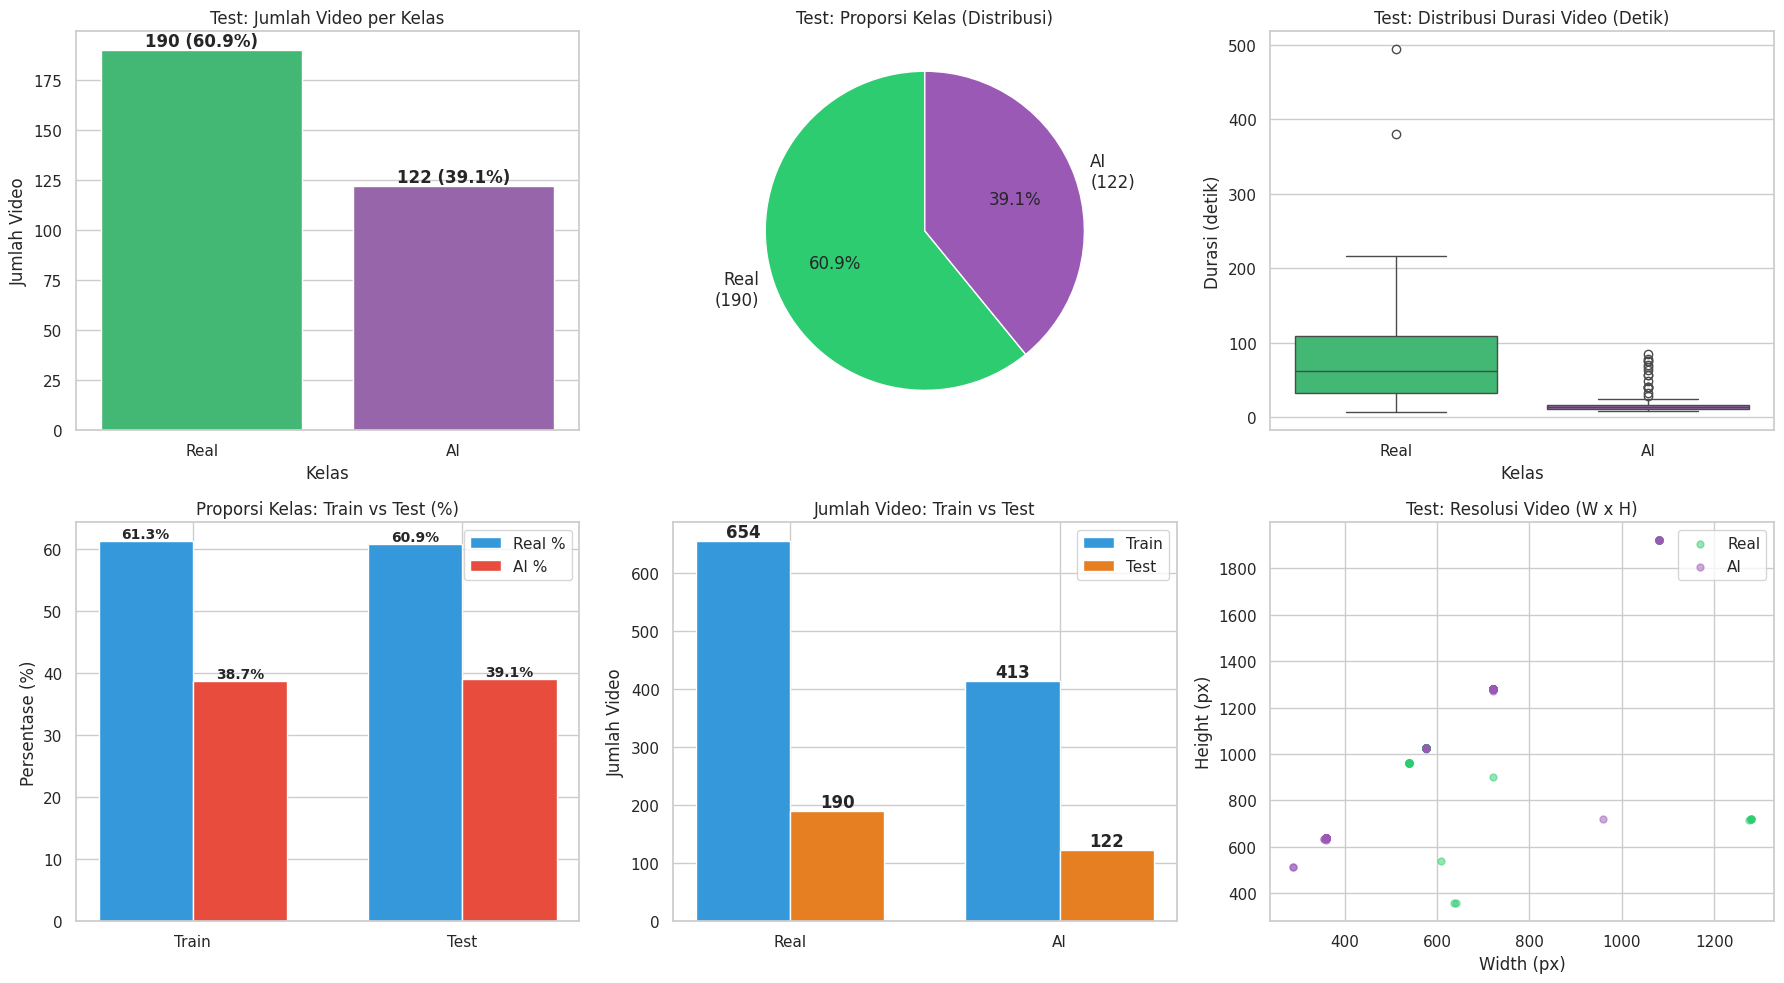

📈 PERBANDINGAN JUMLAH & PROPORSI KELAS: TRAIN vs TEST


,Subset,Total,Real,AI,Real %,AI %
0,Train,1067,654,413,61.29,38.71
1,Test,312,190,122,60.90,39.10


In [7]:
# 7. Visualisasi EDA Dataset Uji (Test) & Perbandingan Train vs Test
test_dist = df_test_eda["class"].value_counts()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1) Jumlah video per kelas
sns.countplot(data=df_test_eda, x="class", hue="class", legend=False, palette=["#2ecc71", "#9b59b6"], ax=axes[0][0])
for i, c in enumerate(CLASSES):
    axes[0][0].text(i, test_dist.get(c, 0), f"{test_dist.get(c, 0)} ({test_dist.get(c, 0) / len(df_test_eda) * 100:.1f}%)", ha="center", va="bottom", fontweight="bold")
axes[0][0].set_title("Test: Jumlah Video per Kelas")
axes[0][0].set_xlabel("Kelas"); axes[0][0].set_ylabel("Jumlah Video")

# 2) Pie chart proporsi kelas
axes[0][1].pie(test_dist.values, labels=[f"{c}\n({v})" for c, v in test_dist.items()], autopct="%1.1f%%",
               colors=["#2ecc71", "#9b59b6"], startangle=90, textprops={"fontsize": 12})
axes[0][1].set_title("Test: Proporsi Kelas (Distribusi)")

# 3) Durasi video
sns.boxplot(data=df_test_eda, x="class", y="duration_sec", hue="class", legend=False, palette=["#2ecc71", "#9b59b6"], ax=axes[0][2])
axes[0][2].set_title("Test: Distribusi Durasi Video (Detik)")
axes[0][2].set_xlabel("Kelas"); axes[0][2].set_ylabel("Durasi (detik)")

# 4) Perbandingan proporsi kelas Train vs Test (persentase)
labels = ["Train", "Test"]
real_pcts = [df_train_eda['class'].value_counts(normalize=True).get('Real', 0) * 100,
             df_test_eda['class'].value_counts(normalize=True).get('Real', 0) * 100]
ai_pcts = [df_train_eda['class'].value_counts(normalize=True).get('AI', 0) * 100,
           df_test_eda['class'].value_counts(normalize=True).get('AI', 0) * 100]
x = np.arange(len(labels)); w = 0.35
axes[1][0].bar(x - w / 2, real_pcts, w, label="Real %", color="#3498db")
axes[1][0].bar(x + w / 2, ai_pcts, w, label="AI %", color="#e74c3c")
for i, (rp, ap) in enumerate(zip(real_pcts, ai_pcts)):
    axes[1][0].text(i - w / 2, rp, f"{rp:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    axes[1][0].text(i + w / 2, ap, f"{ap:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1][0].set_title("Proporsi Kelas: Train vs Test (%)")
axes[1][0].set_ylabel("Persentase (%)"); axes[1][0].set_xticks(x); axes[1][0].set_xticklabels(labels); axes[1][0].legend()

# 5) Jumlah absolut Train vs Test per kelas
x = np.arange(len(CLASSES)); w = 0.35
train_counts = [train_dist.get(c, 0) for c in CLASSES]
test_counts = [test_dist.get(c, 0) for c in CLASSES]
axes[1][1].bar(x - w / 2, train_counts, w, label="Train", color="#3498db")
axes[1][1].bar(x + w / 2, test_counts, w, label="Test", color="#e67e22")
for i, (tc, st) in enumerate(zip(train_counts, test_counts)):
    axes[1][1].text(i - w / 2, tc, f"{tc}", ha="center", va="bottom", fontweight="bold")
    axes[1][1].text(i + w / 2, st, f"{st}", ha="center", va="bottom", fontweight="bold")
axes[1][1].set_title("Jumlah Video: Train vs Test")
axes[1][1].set_ylabel("Jumlah Video"); axes[1][1].set_xticks(x); axes[1][1].set_xticklabels(CLASSES); axes[1][1].legend()

# 6) Resolusi test
for c in CLASSES:
    sub = df_test_eda[df_test_eda["class"] == c]
    axes[1][2].scatter(sub["width"], sub["height"], alpha=0.5, s=25, label=c, color=("#2ecc71" if c == "Real" else "#9b59b6"))
axes[1][2].set_title("Test: Resolusi Video (W x H)")
axes[1][2].set_xlabel("Width (px)"); axes[1][2].set_ylabel("Height (px)"); axes[1][2].legend()

plt.tight_layout()
plt.show()

print("=" * 70)
print("📈 PERBANDINGAN JUMLAH & PROPORSI KELAS: TRAIN vs TEST")
print("=" * 70)
comp_rows = []
for subset, df in [("Train", df_train_eda), ("Test", df_test_eda)]:
    d = df['class'].value_counts()
    r, a = d.get('Real', 0), d.get('AI', 0)
    comp_rows.append({"Subset": subset, "Total": len(df), "Real": r, "AI": a,
                     "Real %": round(r / len(df) * 100, 2), "AI %": round(a / len(df) * 100, 2)})
display(pd.DataFrame(comp_rows))


## 3️⃣ Menjalankan Model untuk Tabel Perbandingan
Dijalankan di notebook ini pada **set test independen** (312 video): **(1)** **base model zero-shot** (`dima806` Video ViT + `MelodyMachine` Audio Wav2Vec2) untuk baris **Fine-tuning = Tidak**, dan **(2)** **Ensemble Multimodal 50/50 hasil fine-tuning** (5-Fold soft-voting) untuk baris **Fine-tuning = Ya**.


In [8]:
# 8. Pre-extract Audio 16kHz Mono untuk Set Test (dibutuhkan inferensi audio)
def extract_audio_from_video(video_path, output_wav_path, target_sr=16000):
    cmd = ["ffmpeg", "-y", "-i", video_path, "-vn", "-acodec", "pcm_s16le", "-ar", str(target_sr), "-ac", "1", output_wav_path]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    if not os.path.exists(output_wav_path) or os.path.getsize(output_wav_path) < 100:
        try:
            y, sr = librosa.load(video_path, sr=target_sr, mono=True)
            sf.write(output_wav_path, y, target_sr)
        except Exception:
            pass

for cls in CLASSES:
    cls_raw_dir = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    cls_audio_dir = os.path.join(LOCAL_AUDIO_TEST_DIR, cls)
    os.makedirs(cls_audio_dir, exist_ok=True)
    if not os.path.exists(cls_raw_dir):
        continue
    for vid in tqdm(glob.glob(os.path.join(cls_raw_dir, "**", "*.mp4"), recursive=True), desc=f"Test Audio Extraction [{cls}]"):
        out_wav = os.path.join(cls_audio_dir, f"{Path(vid).stem}.wav")
        if not os.path.exists(out_wav) or os.path.getsize(out_wav) < 100:
            extract_audio_from_video(vid, out_wav, target_sr=SAMPLE_RATE)
print("✅ Audio test siap!")


Test Audio Extraction [AI]: 100%|██████████| 122/122 [00:00<00:00, 28205.55it/s]

✅ Audio test siap!


In [9]:
# 9. Definisikan Transforms & Loader 5-Fold Split
video_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # dima806 processor (mean=std=0.5)
])

feature_extractor = AutoFeatureExtractor.from_pretrained("MelodyMachine/Deepfake-audio-detection-V2")

if os.path.exists(KFOLD_SPLIT_FILE):
    with open(KFOLD_SPLIT_FILE, "r", encoding="utf-8") as f:
        kfold_splits = json.load(f)
    print(f"✅ Loaded 5-Fold Split: {KFOLD_SPLIT_FILE}")
    print(f"📊 Active Folds: {list(kfold_splits.keys())}")
else:
    raise FileNotFoundError("❌ kfold_splits.json tidak ditemukan! Jalankan generate_kfold_split.ipynb terlebih dahulu.")

print("✅ Transforms & feature extractor siap!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


✅ Loaded 5-Fold Split: /content/drive/MyDrive/Gemastik26/kfold_splits.json
📊 Active Folds: ['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5']
✅ Transforms & feature extractor siap!


🎞️ Pre-extracting frames SEKALI untuk semua video test...


Cache Frames: 100%|██████████| 312/312 [09:43<00:00,  1.87s/it]


🎧 Caching audio features SEKALI...


Cache Audio: 100%|██████████| 312/312 [00:10<00:00, 31.12it/s]


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

[fold_5] Test Ensemble Infer: 100%|██████████| 312/312 [02:22<00:00,  2.20it/s]


⏱️ [fold_5] done in 142s
✅ Evaluated 5 Multimodal Fold Ensembles!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


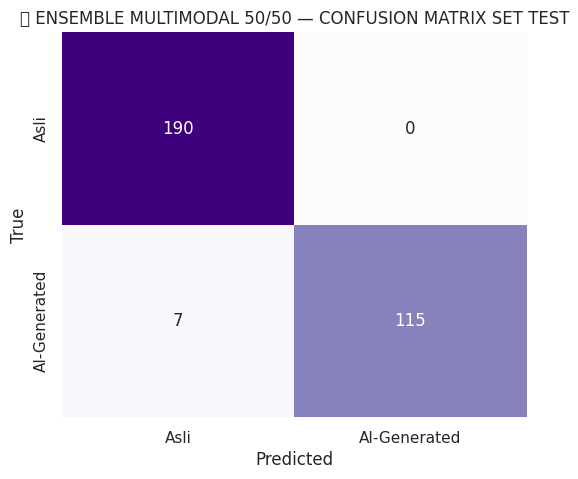


📋 ENSEMBLE MULTIMODAL 50/50 — CLASSIFICATION REPORT (SET TEST)
              precision    recall  f1-score   support

        Asli     0.9645    1.0000    0.9819       190
AI-Generated     1.0000    0.9426    0.9705       122

    accuracy                         0.9776       312
   macro avg     0.9822    0.9713    0.9762       312
weighted avg     0.9784    0.9776    0.9774       312



In [10]:
# 10. 5-FOLD ENSEMBLE INFERENCE (OPTIMIZED: frames diekstrak SEKALI, audio features di-cache)
import gc
import time

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# ---- 1) Pre-extract frames SEKALI ke cache per-session (subdir WAJIB memuat kelas!)
FRAME_CACHE = f"/content/frames_cache_paper_{os.getpid()}"
os.makedirs(FRAME_CACHE, exist_ok=True)

def cache_frames(video_path, out_dir, target_fps=1.0, max_frames=30):
    os.makedirs(out_dir, exist_ok=True)
    existing = sorted(glob.glob(os.path.join(out_dir, "*.jpg")))
    if existing:
        return existing[:max_frames]
    # Tulis BGR array langsung ke JPEG dengan cv2.imwrite (PERSIS seperti notebook target training)
    cap = cv2.VideoCapture(video_path)
    saved_count = 0
    if cap.isOpened():
        video_fps = cap.get(cv2.CAP_PROP_FPS)
        if video_fps <= 0 or np.isnan(video_fps):
            video_fps = 30.0
        frame_interval = max(1, int(round(video_fps / target_fps)))
        count = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if count % frame_interval == 0:
                cv2.imwrite(os.path.join(out_dir, f"f_{saved_count:04d}.jpg"), frame)
                saved_count += 1
                if saved_count >= max_frames:
                    break
            count += 1
        cap.release()
    if saved_count == 0:
        pattern = os.path.join(out_dir, "f_%04d.jpg")
        cmd = ["ffmpeg", "-y", "-i", video_path, "-vf", f"fps={target_fps}", "-frames:v", str(max_frames), pattern]
        subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return sorted(glob.glob(os.path.join(out_dir, "*.jpg")))[:max_frames]

print("🎞️ Pre-extracting frames SEKALI untuk semua video test...")
frame_paths_all = {}
for idx, (vf, true_label, stem) in enumerate(tqdm(test_video_samples, desc="Cache Frames")):
    # CRITICAL: subdir cache memuat label kelas karena testReal.zip & testAI.zip punya stem IDENTIK.
    frame_paths_all[idx] = cache_frames(vf, os.path.join(FRAME_CACHE, CLASSES[true_label], stem), 1.0, 30)

def predict_video_from_frames(frame_paths, video_model, batch_size=32):
    if not frame_paths:
        return 0.5
    all_probs = []
    for i in range(0, len(frame_paths), batch_size):
        batch = frame_paths[i:i + batch_size]
        tensors = torch.stack([video_transform(Image.open(fp).convert('RGB')) for fp in batch]).to(device)
        with torch.inference_mode():
            with torch.amp.autocast("cuda"):
                logits = video_model(tensors).logits
                probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs[:, 1])
        del tensors
    torch.cuda.empty_cache()
    return float(np.mean(np.concatenate(all_probs)))

# ---- 2) Cache audio features SEKALI (wav -> chunks -> input_values), dipakai 5 fold
def precompute_audio_inputs(wav_path):
    if not os.path.exists(wav_path) or os.path.getsize(wav_path) < 100:
        return None
    try:
        waveform = None
        try:
            waveform, sr = torchaudio.load(wav_path)
        except Exception:
            y, sr = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
            waveform = torch.from_numpy(y).unsqueeze(0)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        if sr != SAMPLE_RATE:
            waveform = T.Resample(sr, SAMPLE_RATE)(waveform)
        total_len = waveform.shape[-1]
        chunks = []
        if total_len <= MAX_AUDIO_SAMPLES:
            chunks.append(F.pad(waveform, (0, MAX_AUDIO_SAMPLES - total_len)))
        else:
            for start in range(0, total_len, MAX_AUDIO_SAMPLES):
                chunk = waveform[:, start:start + MAX_AUDIO_SAMPLES]
                if chunk.shape[-1] < MAX_AUDIO_SAMPLES:
                    chunk = F.pad(chunk, (0, MAX_AUDIO_SAMPLES - chunk.shape[-1]))
                chunks.append(chunk)
        return [feature_extractor(c.squeeze(0).numpy(), sampling_rate=SAMPLE_RATE, do_normalize=True, return_tensors="pt").input_values.squeeze(0) for c in chunks]
    except Exception:
        return None

print("🎧 Caching audio features SEKALI...")
audio_inputs_cache = {}
for idx, (vf, true_label, stem) in enumerate(tqdm(test_video_samples, desc="Cache Audio")):
    wav_path = os.path.join(LOCAL_AUDIO_TEST_DIR, CLASSES[true_label], f"{stem}.wav")
    audio_inputs_cache[idx] = precompute_audio_inputs(wav_path)

def predict_audio_from_inputs(inputs_list, audio_model, sub_batch=8):
    if not inputs_list:
        return 0.5
    probs = []
    with torch.inference_mode():
        for i in range(0, len(inputs_list), sub_batch):
            tensors = torch.stack(inputs_list[i:i + sub_batch]).to(device)
            with torch.amp.autocast("cuda"):
                logits = audio_model(tensors).logits
                p = F.softmax(logits, dim=-1).cpu().numpy()
            probs.append(p[:, 0])  # Index 0 = AI untuk MelodyMachine v2
            del tensors
    torch.cuda.empty_cache()
    return float(np.mean(np.concatenate(probs)))

# ---- 3) Inferensi 5-fold ensemble (frames + audio features dimuat SEKALI, dipakai per fold) ----
y_true_test = [lbl for _, lbl, _ in test_video_samples]
sample_v_probs = {idx: [] for idx in range(len(test_video_samples))}
sample_a_probs = {idx: [] for idx in range(len(test_video_samples))}

active_folds_count = 0
for fold_name in kfold_splits.keys():
    v_p = os.path.join(MODEL_SAVE_DIR, f"dima806_deepfake_aug_{fold_name}")
    a_p = os.path.join(AUDIO_MODEL_SAVE_DIR, f"melody_audio_aug_{fold_name}")
    if not os.path.exists(a_p):
        print(f"⚠️ WARNING: Audio v2 checkpoint NOT FOUND at {a_p} — fold skipped.")
    if os.path.exists(v_p) and os.path.exists(a_p):
        active_folds_count += 1
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        vm = AutoModelForImageClassification.from_pretrained(v_p).to(device).eval()
        am = AutoModelForAudioClassification.from_pretrained(a_p).to(device).eval()
        t0 = time.time()
        for idx, (vf, true_label, stem) in enumerate(tqdm(test_video_samples, desc=f"[{fold_name}] Test Ensemble Infer")):
            pv = predict_video_from_frames(frame_paths_all[idx], vm)
            pa = predict_audio_from_inputs(audio_inputs_cache[idx], am)
            sample_v_probs[idx].append(pv)
            sample_a_probs[idx].append(pa)
        print(f"⏱️ [{fold_name}] done in {time.time() - t0:.0f}s")
        del vm, am
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f"✅ Evaluated {active_folds_count} Multimodal Fold Ensembles!")

y_pred_test = []
if active_folds_count > 0 and len(test_video_samples) > 0:
    for idx in range(len(test_video_samples)):
        p_vid_ens = np.mean(sample_v_probs[idx])
        p_aud_ens = np.mean(sample_a_probs[idx])
        p_multimodal = (0.5 * p_vid_ens) + (0.5 * p_aud_ens)  # FUSI 50/50
        y_pred_test.append(1 if p_multimodal >= 0.5 else 0)

    fig, ax = plt.subplots(figsize=(6, 5))
    cm_test = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Purples", cbar=False, ax=ax,
                xticklabels=DISPLAY_LABELS, yticklabels=DISPLAY_LABELS)
    ax.set_title("🧪 ENSEMBLE MULTIMODAL 50/50 — CONFUSION MATRIX SET TEST")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.show()

    print("\n===============================================================")
    print("📋 ENSEMBLE MULTIMODAL 50/50 — CLASSIFICATION REPORT (SET TEST)")
    print("===============================================================")
    print(classification_report(y_true_test, y_pred_test, target_names=DISPLAY_LABELS, digits=4))
else:
    print("ℹ️ Checkpoint fold atau sampel test belum siap untuk evaluasi.")


## 4️⃣ Tabel Perbandingan Model: Visual / Audio / Ensemble × Fine-tuning Tidak/Ya
Semua angka pada tabel ini **dihitung langsung di notebook ini** pada set test independen yang sama (312 video) — bukan hardcoded. Baris **Tidak** berasal dari **base model zero-shot** (Video ViT `dima806` + Audio Wav2Vec2 `MelodyMachine`, mapping empiris label sudah dikoreksi). Baris **Ya** berasal dari hasil **fine-tuning** yang sudah dijalankan di atas (5-Fold ensemble).


In [11]:
# 11. TABEL PERBANDINGAN MODEL (DIHITUNG LIVE DI NOTEBOOK INI — SET TEST SAMA)
# Baris 'Tidak'  = base model zero-shot (Video dima806 + Audio MelodyMachine)
# Baris 'Ya'     = hasil fine-tuning 5-Fold ensemble dari Cell 10

def predict_audio_base_from_inputs(inputs_list, model, sub_batch=8):
    if not inputs_list:
        return 0.5
    probs = []
    with torch.inference_mode():
        for i in range(0, len(inputs_list), sub_batch):
            tensors = torch.stack(inputs_list[i:i + sub_batch]).to(device)
            with torch.amp.autocast("cuda"):
                logits = model(tensors).logits
                p = F.softmax(logits, dim=-1).cpu().numpy()
            probs.append(p[:, 1])  # Empiris: index 1 = AI untuk MelodyMachine base (lihat gemastik_base_model_inference.ipynb)
            del tensors
    torch.cuda.empty_cache()
    return float(np.mean(np.concatenate(probs)))

def compute_metrics(y_true, preds):
    acc = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average="macro", zero_division=0)
    return (round(acc * 100, 2), round(prec * 100, 2), round(rec * 100, 2), round(f1 * 100, 2))

table_rows = []

# ---- a) Fine-tuning = Tidak (BASE MODEL ZERO-SHOT pada set test yang sama) ----
if len(test_video_samples) > 0:
    BASE_VIDEO_ID = "dima806/deepfake_vs_real_image_detection"
    BASE_AUDIO_ID = "MelodyMachine/Deepfake-audio-detection-V2"
    print("⏳ Memuat base model zero-shot (Video dima806 + Audio MelodyMachine) ...")
    base_video_model = AutoModelForImageClassification.from_pretrained(BASE_VIDEO_ID).to(device).eval()
    base_audio_model = AutoModelForAudioClassification.from_pretrained(BASE_AUDIO_ID).to(device).eval()
    print("🚀 Inferensi base model pada set test ...")
    base_v_probs = {}
    base_a_probs = {}
    for idx, (vf, true_label, stem) in enumerate(tqdm(test_video_samples, desc="Base Zero-Shot Infer")):
        base_v_probs[idx] = predict_video_from_frames(frame_paths_all[idx], base_video_model)
        base_a_probs[idx] = predict_audio_base_from_inputs(audio_inputs_cache[idx], base_audio_model)
    del base_video_model, base_audio_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    y_pred_v_base = [1 if base_v_probs[i] >= 0.5 else 0 for i in range(len(test_video_samples))]
    y_pred_a_base = [1 if base_a_probs[i] >= 0.5 else 0 for i in range(len(test_video_samples))]
    y_pred_e_base = [1 if (0.5 * base_v_probs[i] + 0.5 * base_a_probs[i]) >= 0.5 else 0 for i in range(len(test_video_samples))]
    for name, preds in [("Visual", y_pred_v_base), ("Audio", y_pred_a_base), ("Ensemble", y_pred_e_base)]:
        acc, prec, rec, f1 = compute_metrics(y_true_test, preds)
        table_rows.append({"Model": name, "Fine-tuning": "Tidak",
                          "Accuracy (%)": acc, "Precision (%)": prec, "Recall (%)": rec, "F1-Score (%)": f1})

# ---- b) Fine-tuning = Ya (hasil 5-Fold ensemble dari Cell 10) ----
if len(sample_v_probs) > 0 and len(y_pred_test) > 0:
    y_pred_video = [1 if np.mean(sample_v_probs[i]) >= 0.5 else 0 for i in range(len(test_video_samples))]
    y_pred_audio = [1 if np.mean(sample_a_probs[i]) >= 0.5 else 0 for i in range(len(test_video_samples))]
    for name, preds in [("Visual", y_pred_video), ("Audio", y_pred_audio), ("Ensemble", y_pred_test)]:
        acc, prec, rec, f1 = compute_metrics(y_true_test, preds)
        table_rows.append({"Model": name, "Fine-tuning": "Ya",
                          "Accuracy (%)": acc, "Precision (%)": prec, "Recall (%)": rec, "F1-Score (%)": f1})

df_table = pd.DataFrame(table_rows)
print("=" * 78)
print("📊 TABEL PERBANDINGAN MODEL & FINE-TUNING — HASIL LIVE SET TEST INDEPENDEN")
print("=" * 78)
display(df_table)


⏳ Memuat base model zero-shot (Video dima806 + Audio MelodyMachine) ...


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  343MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

🚀 Inferensi base model pada set test ...


Base Zero-Shot Infer: 100%|██████████| 312/312 [02:21<00:00,  2.21it/s]


📊 TABEL PERBANDINGAN MODEL & FINE-TUNING — HASIL LIVE SET TEST INDEPENDEN


,Model,Fine-tuning,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Visual,Tidak,58.97,30.07,48.42,37.10
1,Audio,Tidak,65.06,64.99,65.74,64.62
2,Ensemble,Tidak,77.88,80.43,73.33,74.41
3,Visual,Ya,96.15,97.03,95.08,95.88
4,Audio,Ya,97.44,97.98,96.72,97.27
5,Ensemble,Ya,97.76,98.22,97.13,97.62


## 5️⃣ Visualisasi Perbandingan Setiap Model
Bar chart Accuracy/Precision/Recall/F1 per modalitas (Visual / Audio / Ensemble) berdasarkan tabel **live** `df_table` (base zero-shot vs fine-tuned pada set test yang sama), plus heatmap dan perbandingan hasil inferensi terbaru.


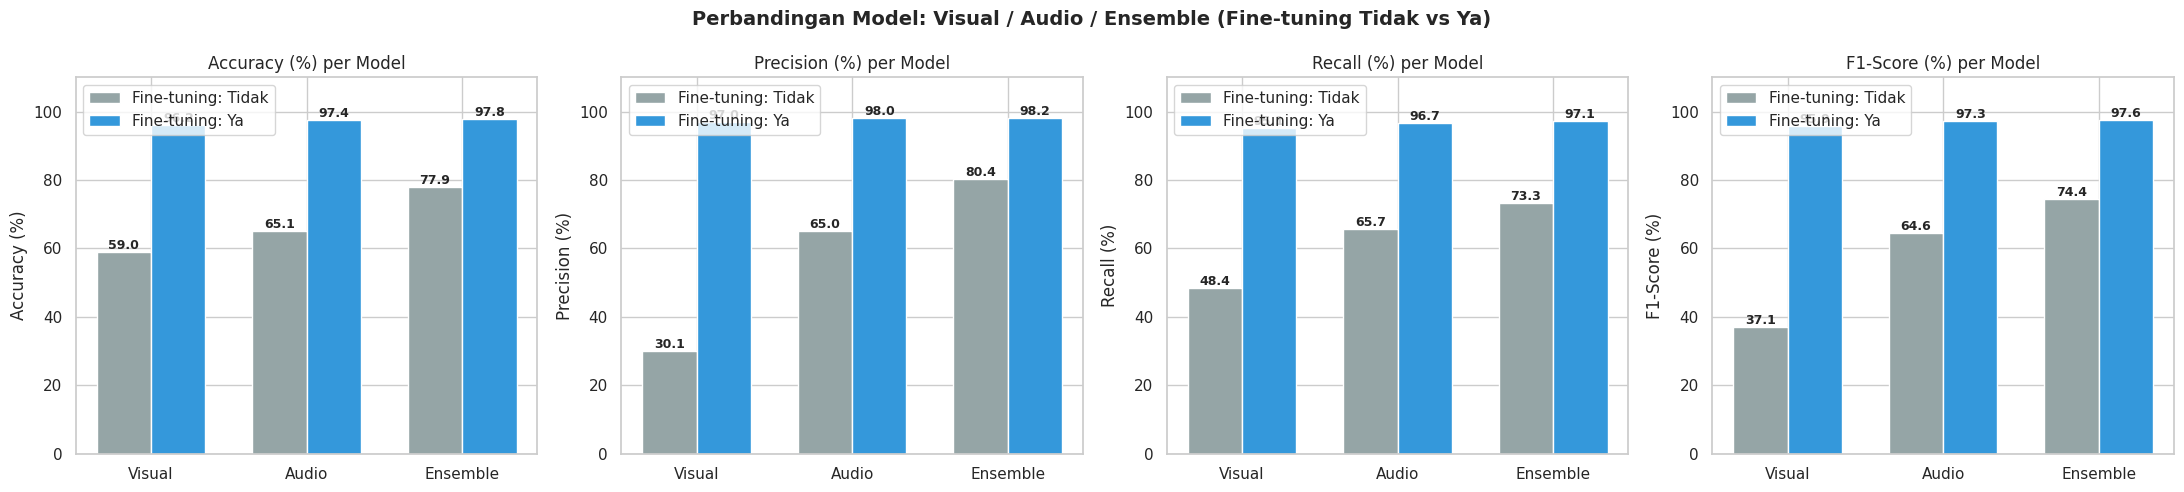

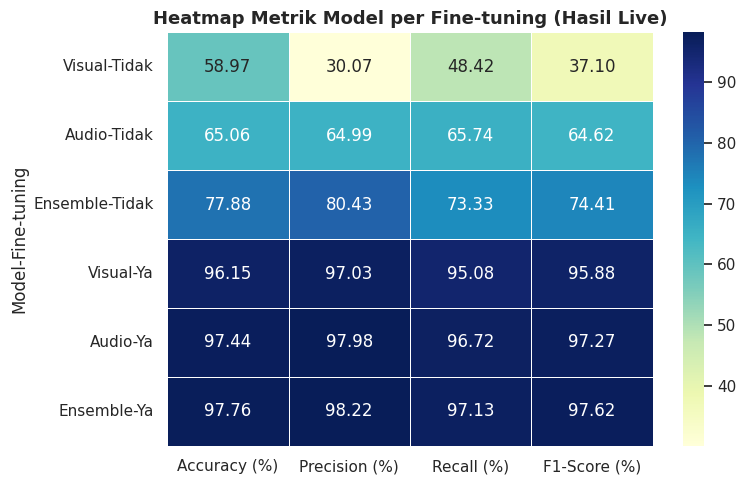

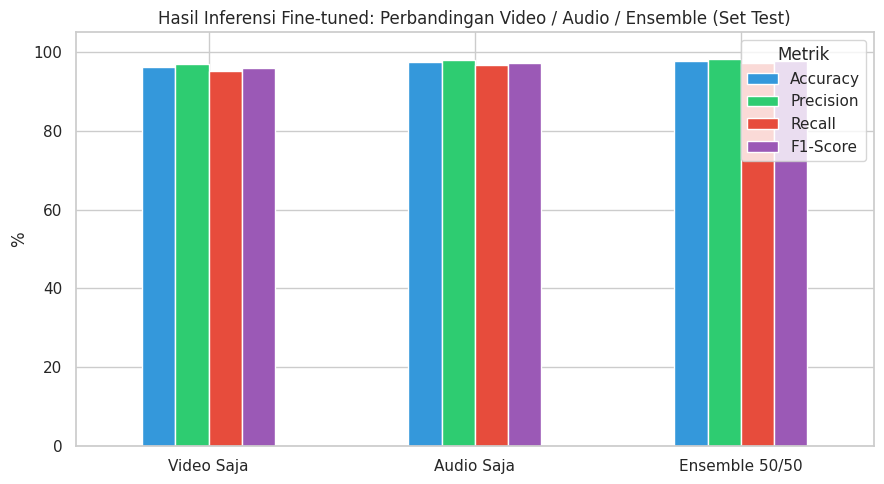

In [12]:
# 12. 📊 Visualisasi Perbandingan Setiap Model (berdasarkan tabel live)
model_order = ["Visual", "Audio", "Ensemble"]
metric_cols = ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1-Score (%)"]

# 1) Grouped bar chart per metrik (Fine-tuning Tidak vs Ya)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, m in zip(axes, metric_cols):
    pivot = df_table.pivot(index="Model", columns="Fine-tuning", values=m).reindex(model_order)
    x = np.arange(len(model_order)); w = 0.35
    bars1 = ax.bar(x - w / 2, pivot["Tidak"], w, label="Fine-tuning: Tidak", color="#95a5a6")
    bars2 = ax.bar(x + w / 2, pivot["Ya"], w, label="Fine-tuning: Ya", color="#3498db")
    for bars in (bars1, bars2):
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():.1f}",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(f"{m} per Model")
    ax.set_ylabel(m)
    ax.set_xticks(x); ax.set_xticklabels(model_order)
    ax.set_ylim(0, 110)
    ax.legend()
plt.suptitle("Perbandingan Model: Visual / Audio / Ensemble (Fine-tuning Tidak vs Ya)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 2) Heatmap tabel live
plt.figure(figsize=(8, 5))
hm = df_table.set_index(["Model", "Fine-tuning"])[metric_cols].astype(float)
sns.heatmap(hm, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, linewidths=0.5)
plt.title("Heatmap Metrik Model per Fine-tuning (Hasil Live)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 3) Perbandingan metrik hasil inferensi terbaru (fine-tuned) antar modalitas
if len(sample_v_probs) > 0 and len(y_pred_test) > 0:
    y_pred_video = [1 if np.mean(sample_v_probs[i]) >= 0.5 else 0 for i in range(len(test_video_samples))]
    y_pred_audio = [1 if np.mean(sample_a_probs[i]) >= 0.5 else 0 for i in range(len(test_video_samples))]
    mods = {}
    for name, preds in [("Video Saja", y_pred_video), ("Audio Saja", y_pred_audio), ("Ensemble 50/50", y_pred_test)]:
        acc = accuracy_score(y_true_test, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(y_true_test, preds, average="macro", zero_division=0)
        mods[name] = [acc * 100, prec * 100, rec * 100, f1 * 100]

    df_mods = pd.DataFrame(mods, index=["Accuracy", "Precision", "Recall", "F1-Score"])
    fig, ax = plt.subplots(figsize=(9, 5))
    df_mods.T.plot(kind="bar", ax=ax, color=["#3498db", "#2ecc71", "#e74c3c", "#9b59b6"])
    ax.set_title("Hasil Inferensi Fine-tuned: Perbandingan Video / Audio / Ensemble (Set Test)")
    ax.set_ylabel("%"); ax.set_ylim(0, 105)
    ax.legend(title="Metrik")
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()


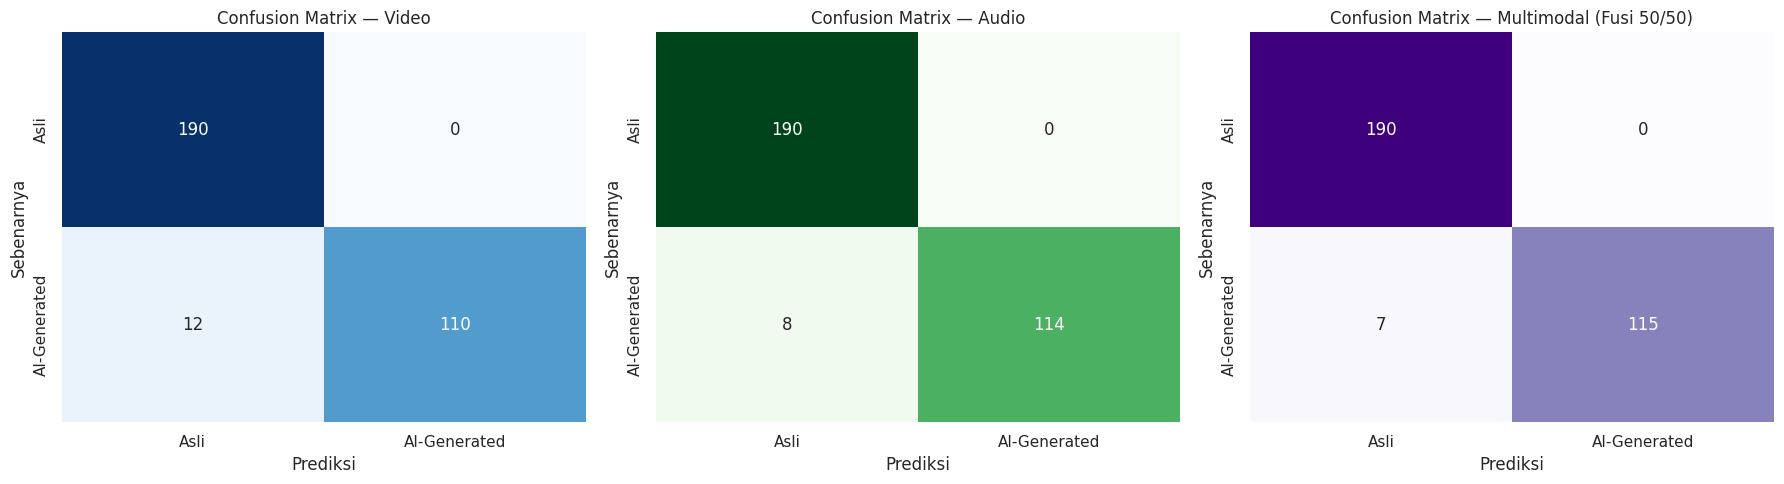

In [13]:
# 13. Confusion Matrix Perbandingan Modalitas (Hasil Inferensi Terbaru, Set Test)
if len(sample_v_probs) > 0 and len(y_pred_test) > 0:
    y_pred_video = [1 if np.mean(sample_v_probs[i]) >= 0.5 else 0 for i in range(len(test_video_samples))]
    y_pred_audio = [1 if np.mean(sample_a_probs[i]) >= 0.5 else 0 for i in range(len(test_video_samples))]
    modalities = {"Video": y_pred_video, "Audio": y_pred_audio, "Multimodal (Fusi 50/50)": y_pred_test}
    cmaps = ["Blues", "Greens", "Purples"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, preds), cmap in zip(axes, modalities.items(), cmaps):
        cm = confusion_matrix(y_true_test, preds, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax,
                    xticklabels=DISPLAY_LABELS, yticklabels=DISPLAY_LABELS)
        ax.set_title(f"Confusion Matrix — {name}")
        ax.set_xlabel("Prediksi"); ax.set_ylabel("Sebenarnya")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Jalankan Cell 10 terlebih dahulu!")
